# **AI/ML Explore 5 - Perspective Transforming using Keypoints Detection**

In [ ]:
!nvidia-smi # make sure we have access to GPU (A100 GPU is preferred for this workshop)

Mon Mar 30 21:33:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   36C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import os

HOME = os.getcwd()
print(HOME)

/content


### **Install Dependencies**

In [ ]:
!pip install -q ultralytics roboflow gdown supervision inference-gpu tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 11.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 87.1 MB/s eta 0:00:00
  Installing build de

### **Import**

In [ ]:
from roboflow import Roboflow
from google.colab import userdata
from IPython.display import Image

### **Retrieve Dataset**

In [ ]:
# Create the folder only if it doesn't exist
datasets_path = f"{HOME}/datasets"
os.makedirs(datasets_path, exist_ok=True)
os.chdir(datasets_path)

In [ ]:
# Retrieve Roboflow API Key from secret
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

# Initialize connection to Roboflow using your API key
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Access a specific workspace and project on Roboflow
# Workspace: "roboflow-jvuqo" (the account/team name)
# Project: "football-field-detection-f07vi" (the dataset project)
project = rf.workspace("roboflow-jvuqo").project("football-field-detection-f07vi")
version = project.version(15)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-field-detection-15 in yolov8:: 100%|██████████| 646/646 [00:00<00:00, 6646.31it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### **Custom Training**

In [ ]:
from ultralytics import YOLO

In [ ]:
# Load the YOLOv8 extra-large model with pretrained weights (trained on COCO dataset)
model = YOLO("yolov8x-pose.pt")

# Store training metrics and metadata
results = model.train(
    task='pose', # task type
    data=f"{dataset.location}/data.yaml", # path to the data.yaml config file
    batch=48, # number of images processed at once
    epochs=500, # number of complete passes through the entire dataset
    imgsz=640, # resize all images to 640x640 pixels
    mosaic=0.0, # normally YOLO stitches 4 random training images into one combined image to help the model learn at different scales and contexts. Setting it to 0.0 turns this off, which makes sense for pose estimation because the stitching can warp or misalign keypoint annotations.
    # degrees=5.0,      # random rotation up to 15 degrees
    # translate=0.2,      # random shift up to 20%
    # scale=0.5,          # random zoom 50-150%
    # fliplr=0.5,         # horizontal flip 50% of the time
    # hsv_h=0.015,        # slight hue variation
    # hsv_s=0.7,          # saturation variation
    # hsv_v=0.4,          # brightness variation
    plots=True # generate training plots (loss curves, confusion matrix, PR curves, etc.)
)



Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=48, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/football-field-detection-15/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=500, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m-pose.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

In [ ]:
from google.colab import files

files.download(f"{HOME}/datasets/runs/pose/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **Pitch Keypoint Detection**

In [ ]:
cd ..

/content


In [ ]:
# !gdown --fuzzy "https://drive.google.com/file/d/1AuKxRSAq69YPoPFaxa6Vv677lf5mbmsD/view?usp=sharing" -O "Football_C.mp4"
!gdown --fuzzy "https://drive.google.com/uc?id=1vVwjW1dE1drIdd4ZSILfbCGPD4weoNiu" -O "Football_C.mp4"

# !gdown --fuzzy "https://drive.google.com/file/d/1s0nyabnUX1DaHoRgzH07F_s_vc_xYu35/view?usp=sharing" -O "keypoint_detection_model.pt"
# !gdown --fuzzy "https://drive.google.com/file/d/1Hh-9yjHLY_yRL2g9kYQjB3YhOrbMkKsW/view?usp=sharing" -O "keypoint_detection_model_v8.pt"
!gdown --fuzzy "https://drive.google.com/file/d/1WFGR1pF5Uy5ee40YXaBs9b4T8hHu4w6p/view?usp=sharing" -O "object_detection_model.pt"

Downloading...
From: https://drive.google.com/uc?id=1vVwjW1dE1drIdd4ZSILfbCGPD4weoNiu
To: /content/Football_C.mp4
100% 17.2M/17.2M [00:00<00:00, 31.9MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1WFGR1pF5Uy5ee40YXaBs9b4T8hHu4w6p
From (redirected): https://drive.google.com/uc?id=1WFGR1pF5Uy5ee40YXaBs9b4T8hHu4w6p&confirm=t&uuid=d53dd8ae-5ab3-4347-a044-f5e2301b240c
To: /content/object_detection_model.pt
100% 118M/118M [00:02<00:00, 50.3MB/s]


In [ ]:
from inference import get_model

KEYPOINT_DETECTION_MODEL_ID = "football-field-detection-f07vi/15"
KEYPOINT_DETECTION_MODEL = get_model(model_id=KEYPOINT_DETECTION_MODEL_ID, api_key=ROBOFLOW_API_KEY)

ModelDependencyMissing: Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
ModelDependencyMissing: Your `inference` configuration does not support Gaze Detection model. Use pip install 'inference[gaze]' to install missing requirements.To suppress this warning, set CORE_MODEL_GAZE_ENABLED to False.


Output()

In [ ]:
import supervision as sv
import numpy as np

# Retrieve the model from the path, and assign it to the variable
# Assign video path to the variable
# KEYPOINT_DETECTION_MODEL = YOLO("/content/keypoint_detection_model_v8.pt")
SOURCE_VIDEO_PATH = "/content/Football_C.mp4"
OUTPUT_VIDEO_PATH = "/content/Football_C_Output.mp4"

# Annotator for keypoints from Supervision
vertex_annotator = sv.VertexAnnotator(
    color=sv.Color.from_hex('#FF1493'),
    radius=8
)

# Get video info (resolution, fps, total frames)
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

# Open a video writer that matches the source video's settings
with sv.VideoSink(target_path=OUTPUT_VIDEO_PATH, video_info=video_info) as sink:
    # Loop through every frame instead of just the first one
    for frame in sv.get_video_frames_generator(SOURCE_VIDEO_PATH):
        result = KEYPOINT_DETECTION_MODEL.infer(frame, confidence=0.3)[0]
        key_points = sv.KeyPoints.from_inference(result)

        # If no field detected, write the original frame and skip
        if key_points.confidence is None or len(key_points.confidence) == 0:
            sink.write_frame(frame)
            continue

        # Filter keypoints by confidence
        filter = key_points.confidence[0] > 0.5
        frame_reference_points = key_points.xy[0][filter]
        frame_reference_key_points = sv.KeyPoints(
            xy=frame_reference_points[np.newaxis, ...]
        )

        annotated_frame = frame.copy()
        annotated_frame = vertex_annotator.annotate(
            scene=annotated_frame,
            key_points=frame_reference_key_points
        )
        sink.write_frame(annotated_frame)

# # Create a lazy iterator for the football video, and assing it to the variable
# frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
# frame = next(frame_generator) # retrieve the first frame

# # Run the model on the frame to check if there are a football field
# result = MODEL(frame, conf=0.3)[0]
# key_points = sv.KeyPoints.from_ultralytics(result) # Convert YOLO output into supervision's KeyPoints format

# # Filter, only keep keypoint that have more than 0.5 confidence score
# filter = key_points.confidence[0] > 0.5 # keypoints confidence list [0.9, 0.3, 0.8, 0.2, 0.7] -> filter = [True, False, True, False, True]
# frame_reference_points = key_points.xy[0][filter] # Apply the above mask to coordinates to only keeps the entries where the mask says 'True' | [0] only grab (32, 2) instead of (1, 32, 2)
# frame_reference_key_points = sv.KeyPoints( # KeyPoints format expect (num_detection, num_keypoint, 2) format
#     xy=frame_reference_points[np.newaxis, ...] # adds the num_detections dimension back (a new axis in front) | (20, 2) → (1, 20, 2)
# )

# # Before filtering - (1, 32, 2) | (num_detection, num_keypoint, 2)
# # After filtering - (20, 2) | (num_keypoint, 2)

# annotated_frame = frame.copy()  # work on a copy so the original stays clean
# annotated_frame = vertex_annotator.annotate(
#     scene=annotated_frame, # the image to draw on
#     key_points=frame_reference_key_points # the filtered keypoints to draw
# )

# # Display the result
# sv.plot_image(annotated_frame)


### **Homography: Virtual Lines & Field Overlay**

In [ ]:
!pip install -q git+https://github.com/roboflow/sports.git # install sport repo that cotains a variety of football related utilities that we going to use

  Preparing metadata (setup.py) ... done


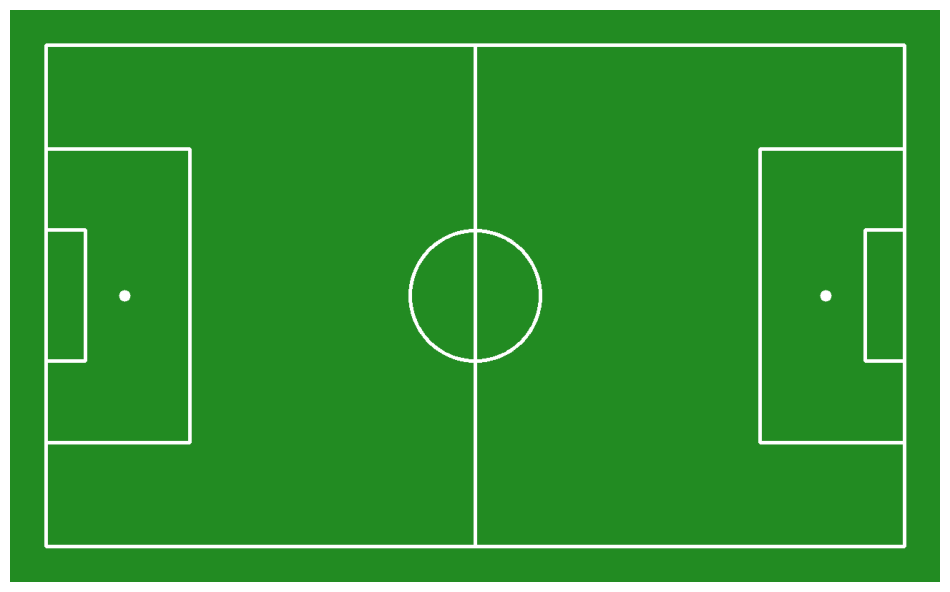

In [ ]:
from sports.configs.soccer import SoccerPitchConfiguration # import an object that stores info about 32 points coordinate of a football field
from sports.annotators.soccer import draw_pitch # annotator that will be use to draw pitch

CONFIG = SoccerPitchConfiguration()
annotated_frame = draw_pitch(CONFIG) # take those 32 keypoints and draw the pitch lines on a blank image

sv.plot_image(annotated_frame) # plot the frame

In [ ]:
# findHomography takes those matched pairs and figures out the 3×3 matrix that maps one to the other
CONFIG.edges

[(1, 2),
 (2, 3),
 (3, 4),
 (4, 5),
 (5, 6),
 (7, 8),
 (10, 11),
 (11, 12),
 (12, 13),
 (14, 15),
 (15, 16),
 (16, 17),
 (18, 19),
 (19, 20),
 (20, 21),
 (23, 24),
 (25, 26),
 (26, 27),
 (27, 28),
 (28, 29),
 (29, 30),
 (1, 14),
 (2, 10),
 (3, 7),
 (4, 8),
 (5, 13),
 (6, 17),
 (14, 25),
 (18, 26),
 (23, 27),
 (24, 28),
 (21, 29),
 (17, 30)]

In [ ]:
import cv2

class ViewTransformer:
  def __init__(self, source: np.ndarray, target: np.ndarray):
    source = source.astype(np.float32) # keypoints from the video frame (camera view)
    target = target.astype(np.float32) # matching keypoints from the 2D pitch diagram
    self.m, _ = cv2.findHomography(source, target) # compute the 3x3 transformation matrix

  # Uses transformation matrix to convert any point from camera view to pitch view
  def transform_points(self, points: np.ndarray) -> np.ndarray:
    points = points.reshape(-1, 1, 2).astype(np.float32) # reshape to what OpenCV expects: (N, 1, 2)
    points = cv2.perspectiveTransform(points, self.m) # apply the homography matrix
    return points.reshape(-1, 2).astype(np.float32) # reshape back to simple (N, 2)

In [ ]:
vertex_annotator = sv.VertexAnnotator(
    color=sv.Color.from_hex('#FF1493'),
    radius=8
)

edge_annotator = sv.EdgeAnnotator(
    color=sv.Color.from_hex('#00BFFF'),
    thickness=2,
    edges=CONFIG.edges
)

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

def is_homography_valid(src_pts, dst_pts, threshold=10.0):
    """Reproject source points and check if they land close to destination."""
    H, _ = cv2.findHomography(src_pts, dst_pts)
    if H is None:
        return False

    projected = cv2.perspectiveTransform(
        src_pts.reshape(-1, 1, 2).astype(np.float32), H
    ).reshape(-1, 2)

    errors = np.linalg.norm(projected - dst_pts, axis=1)
    mean_error = errors.mean()

    return mean_error < threshold

last_good_transformer = None  # track last valid homography

with sv.VideoSink(target_path=OUTPUT_VIDEO_PATH, video_info=video_info) as sink:
    for frame in sv.get_video_frames_generator(SOURCE_VIDEO_PATH):
        result = KEYPOINT_DETECTION_MODEL.infer(frame, confidence=0.3)[0]
        key_points = sv.KeyPoints.from_inference(result)

        # If no field detected, write original frame and skip
        if key_points.confidence is None or len(key_points.confidence) == 0:
            sink.write_frame(frame)
            continue

        # Pick the most confident detection
        best = key_points.confidence.sum(axis=1).argmax()

        # Filter keypoints by confidence — raised from 0.5 to 0.7
        filter = key_points.confidence[best] > 0.7
        frame_reference_points = key_points.xy[best][filter]
        pitch_reference_points = np.array(CONFIG.vertices)[:len(filter)][filter]

        # Require at least 6 points for a stable homography — raised from 4
        if filter.sum() < 6:
            sink.write_frame(frame)
            continue

        # Validate the homography before using it
        if is_homography_valid(pitch_reference_points, frame_reference_points):
            view_transformer = ViewTransformer(
                source=pitch_reference_points,
                target=frame_reference_points
            )
            last_good_transformer = view_transformer  # save last good one
        elif last_good_transformer is not None:
            view_transformer = last_good_transformer  # reuse last good one
        else:
            sink.write_frame(frame)  # no good frame yet, skip
            continue

        frame_reference_key_points = sv.KeyPoints(
            xy=frame_reference_points[np.newaxis, ...]
        )

        # Transform all pitch points to frame
        pitch_all_points = np.array(CONFIG.vertices)
        frame_all_points = view_transformer.transform_points(pitch_all_points)
        frame_all_key_points = sv.KeyPoints(xy=frame_all_points[np.newaxis, ...])

        # Annotate
        annotated_frame = frame.copy()
        annotated_frame = edge_annotator.annotate(annotated_frame, frame_all_key_points)
        annotated_frame = vertex_annotator.annotate(
            scene=annotated_frame,
            key_points=frame_reference_key_points
        )
        sink.write_frame(annotated_frame)

### **Video Visualization**

In [ ]:
from tqdm import tqdm

SOURCE_VIDEO_PATH = "/content/Football_C.mp4"
OBJECT_DETECTION_MODEL = YOLO("/content/object_detection_model.pt")
STRIDE = 30 # instead of process each frame at one time, process 1 frame every 30 frame
PLAYER_ID = 2 # id for player (0 = ball, 1 = goalkeeper, 2 = player, 3 = referee)

def extract_crops(source_video_path: str):
  crops = []
  frame_generator = sv.get_video_frames_generator(source_video_path, stride=STRIDE) # creates a lazy iterator that yields one frame at a time


  for frame in tqdm(frame_generator, desc="Extracting crops"):
    result = OBJECT_DETECTION_MODEL(frame, conf=0.3)[0] # runs YOLO on the current frame, only keeping detections with 30%+ confidence
    detections = sv.Detections.from_ultralytics(result) # turn YOLO output to SV Detection Object
    detections = detections.with_nms(threshold=0.5, class_agnostic=True) # remove duplicate box from YOLO output
    detections = detections[detections.class_id == PLAYER_ID] # take only the player detection
    # Extract crops
    crops += [
        sv.crop_image(frame, xyxy) # cut out the exact rectangle from the frame according to xyxy coordinate (top left coor and bottom right coor)
        for xyxy
        in detections.xyxy # give the coordinate of the box
    ]

  return crops # numpy array format

In [ ]:
def resolve_goalkeepers_team_id(
    players: sv.Detections,
    goalkeepers: sv.Detections
) -> np.ndarray:

  # Get the bottom center coord of each bounding box
  # Why bottom center? -> more accurate because it is feet position
  goalkeepers_xy = goalkeepers.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
  players_xy = players.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)

  # Filters players by team ID (0 or 1)
  # Average all their positions to find the center point of each team
  team_0_centroid = players_xy[players.class_id == 0].mean(axis=0)
  team_1_centroid = players_xy[players.class_id == 1].mean(axis=0)

  goalkeepers_team_id = []

  # Assign each goalkeeper
  for goalkeeper_xy in goalkeepers_xy:
    # Calculate the distance (Euclidean distance) between current goalkeeper coord and current team coord
    dist_0 = np.linalg.norm(goalkeeper_xy - team_0_centroid)
    dist_1 = np.linalg.norm(goalkeeper_xy - team_1_centroid)

    # goalkeepers id is 0 if closer to team 0, and vice versa
    goalkeepers_team_id.append(0 if dist_0 < dist_1 else 1)

  # Returns an array of team IDs, one per goalkeeper
  return np.array(goalkeepers_team_id)


In [ ]:
from sports.common.team import TeamClassifier
from sports.annotators.soccer import draw_points_on_pitch
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BALL_ID = 0
GOALKEEPER_ID = 1
PLAYER_ID = 2
REFEREE_ID = 3

SOURCE_VIDEO_PATH = "/content/Football_C.mp4"
OUTPUT_VIDEO_PATH = "/content/Football_C_Map.mp4"

# Train team classifier on crops from the video
crops = extract_crops(SOURCE_VIDEO_PATH)
team_classifier = TeamClassifier(device=DEVICE)
team_classifier.fit(crops)

# Initialize tracker
tracker = sv.ByteTrack()
tracker.reset()

# Get video info and create output video with pitch dimensions
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
pitch_frame = draw_pitch(config=CONFIG)
pitch_h, pitch_w = pitch_frame.shape[:2]
pitch_video_info = sv.VideoInfo(
    width=pitch_w,
    height=pitch_h,
    fps=video_info.fps
)

with sv.VideoSink(target_path=OUTPUT_VIDEO_PATH, video_info=pitch_video_info) as sink:
    for frame in sv.get_video_frames_generator(SOURCE_VIDEO_PATH):

        # --- Object Detection ---
        result = OBJECT_DETECTION_MODEL(frame, conf=0.3)[0]
        detections = sv.Detections.from_ultralytics(result)

        ball_detections = detections[detections.class_id == BALL_ID]
        ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)

        all_detections = detections[detections.class_id != BALL_ID]
        all_detections = all_detections.with_nms(threshold=0.5, class_agnostic=True)
        all_detections = tracker.update_with_detections(detections=all_detections)

        goalkeepers_detections = all_detections[all_detections.class_id == GOALKEEPER_ID]
        players_detections = all_detections[all_detections.class_id == PLAYER_ID]
        referees_detections = all_detections[all_detections.class_id == REFEREE_ID]

        # --- Team Classification ---
        players_crops = [sv.crop_image(frame, xyxy) for xyxy in players_detections.xyxy]
        if len(players_crops) > 0:
            players_detections.class_id = team_classifier.predict(players_crops)

        if len(goalkeepers_detections) > 0 and len(players_detections) > 0:
            goalkeepers_detections.class_id = resolve_goalkeepers_team_id(
                players_detections, goalkeepers_detections)

        # --- Keypoint Detection & Homography ---
        result = KEYPOINT_DETECTION_MODEL.infer(frame, confidence=0.3)[0]
        key_points = sv.KeyPoints.from_inference(result)

        if key_points.confidence is None or len(key_points.confidence) == 0:
            sink.write_frame(draw_pitch(config=CONFIG))
            continue

        best = key_points.confidence.sum(axis=1).argmax()
        filter = key_points.confidence[best] > 0.5

        if filter.sum() < 4:
            sink.write_frame(draw_pitch(config=CONFIG))
            continue

        frame_reference_points = key_points.xy[best][filter]
        pitch_reference_points = np.array(CONFIG.vertices)[:len(filter)][filter]

        transformer = ViewTransformer(
            source=frame_reference_points,
            target=pitch_reference_points
        )

        # --- Transform positions to pitch coordinates ---
        pitch = draw_pitch(config=CONFIG)

        if len(ball_detections) > 0:
            frame_ball_xy = ball_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
            pitch_ball_xy = transformer.transform_points(points=frame_ball_xy)
            pitch = draw_points_on_pitch(
                config=CONFIG, xy=pitch_ball_xy,
                face_color=sv.Color.WHITE, edge_color=sv.Color.BLACK,
                radius=10, pitch=pitch)

        if len(players_detections) > 0:
            players_xy = players_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
            pitch_players_xy = transformer.transform_points(points=players_xy)
            pitch = draw_points_on_pitch(
                config=CONFIG, xy=pitch_players_xy[players_detections.class_id == 0],
                face_color=sv.Color.from_hex("00BFFF"), edge_color=sv.Color.BLACK,
                radius=16, pitch=pitch)
            pitch = draw_points_on_pitch(
                config=CONFIG, xy=pitch_players_xy[players_detections.class_id == 1],
                face_color=sv.Color.from_hex("FF1493"), edge_color=sv.Color.BLACK,
                radius=16, pitch=pitch)

        if len(referees_detections) > 0:
            referees_xy = referees_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
            pitch_referees_xy = transformer.transform_points(points=referees_xy)
            pitch = draw_points_on_pitch(
                config=CONFIG, xy=pitch_referees_xy,
                face_color=sv.Color.from_hex("FFD700"), edge_color=sv.Color.BLACK,
                radius=16, pitch=pitch)

        sink.write_frame(pitch)

Extracting crops: 0it [00:00, ?it/s]


0: 736x1280 2 balls, 1 goalkeeper, 21 players, 2 referees, 19.3ms
Speed: 6.8ms preprocess, 19.3ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 1 ball, 1 goalkeeper, 21 players, 2 referees, 21.6ms
Speed: 9.9ms preprocess, 21.6ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)


Extracting crops: 2it [00:00, 11.13it/s]


0: 736x1280 2 balls, 21 players, 2 referees, 20.0ms
Speed: 10.3ms preprocess, 20.0ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 1 ball, 21 players, 2 referees, 20.9ms
Speed: 7.6ms preprocess, 20.9ms inference, 0.6ms postprocess per image at shape (1, 3, 736, 1280)


Extracting crops: 4it [00:00, 11.47it/s]

...


Embedding extraction: 1it [00:00, 12.96it/s]



0: 736x1280 22 players, 2 referees, 20.4ms
Speed: 8.5ms preprocess, 20.4ms inference, 0.6ms postprocess per image at shape (1, 3, 736, 1280)


Embedding extraction: 1it [00:00, 13.03it/s]



0: 736x1280 1 ball, 21 players, 2 referees, 21.0ms
Speed: 8.2ms preprocess, 21.0ms inference, 0.6ms postprocess per image at shape (1, 3, 736, 1280)


Embedding extraction: 1it [00:00, 12.26it/s]
